# FASE 5 — Classificador de Tickets e Busca Semântica
**Challenge 002 — Redesign de Suporte (G4 Educação)** · Autor: Thales Barbosa · 2026-07-17

**Dataset:** D2 (47.823 tickets reais de TI, 8 classes — pós-filtro da FASE 2).
**Treino:** executado por [`src/train_models.py`](../src/train_models.py) (1x; ~20-40 min de embeddings em CPU);
este notebook **carrega os artefatos** de `models/` e apresenta resultados — re-treinar = rodar o script.
**Diretrizes (D-007):** split estratificado 80/20 seed 42; macro-F1 como métrica principal (desbalanceamento
7,7:1); mapeamento de classes congelado (`TOPIC_CLASSES`); Miscellaneous via threshold de confiança.
**Consumo:** o protótipo (FASE 6) usa `load_ticket_ai()` — classificação com gate de confiança + busca
semântica FAISS — exatamente o contrato do fluxo da FASE 4 (§6).

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_prep import TOPIC_CLASSES
from src.ticket_ai import MODELS_DIR, load_ticket_ai

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
BLUE = sns.color_palette("deep")[0]
ASSETS = Path("../docs/assets")

metrics = json.loads((MODELS_DIR / "metrics.json").read_text(encoding="utf-8"))
preds = pd.read_parquet(MODELS_DIR / "predictions.parquet")
print(f"Split: {metrics['split']['train']:,} treino / {metrics['split']['test']:,} teste "
      f"(estratificado, seed {metrics['split']['seed']})")
print(f"Tempo total de treino/comparação: {metrics['train_seconds']/60:.0f} min")

Split: 38,258 treino / 9,565 teste (estratificado, seed 42)
Tempo total de treino/comparação: 1 min


## 1. Comparação dos candidatos (exigência do plano: TF-IDF, Sentence Transformers, Embeddings)

In [2]:
comp = pd.DataFrame([{k: r[k] for k in
    ["model", "accuracy", "precision_macro", "recall_macro", "f1_macro", "f1_weighted"]}
    for r in metrics["results"]]).set_index("model").round(4)
print(comp.to_string())
print(f"\nVENCEDOR: {metrics['winner']}")

              accuracy  precision_macro  recall_macro  f1_macro  f1_weighted
model                                                                       
tfidf_logreg    0.8653           0.8960        0.8402    0.8652       0.8654
tfidf_linsvc    0.8657           0.8860        0.8502    0.8669       0.8657
embed_logreg    0.8073           0.8303        0.7963    0.8118       0.8072

VENCEDOR: tfidf_logreg


## 2. Vencedor — F1 por classe e matriz de confusão

                       precision  recall  f1-score  support
Access                     0.905   0.884     0.895   1425.0
Administrative rights      0.901   0.696     0.785    352.0
HR Support                 0.868   0.882     0.875   2182.0
Hardware                   0.819   0.888     0.852   2722.0
Internal Project           0.935   0.811     0.869    424.0
Miscellaneous              0.837   0.841     0.839   1412.0
Purchase                   0.964   0.880     0.920    493.0
Storage                    0.940   0.840     0.887    555.0


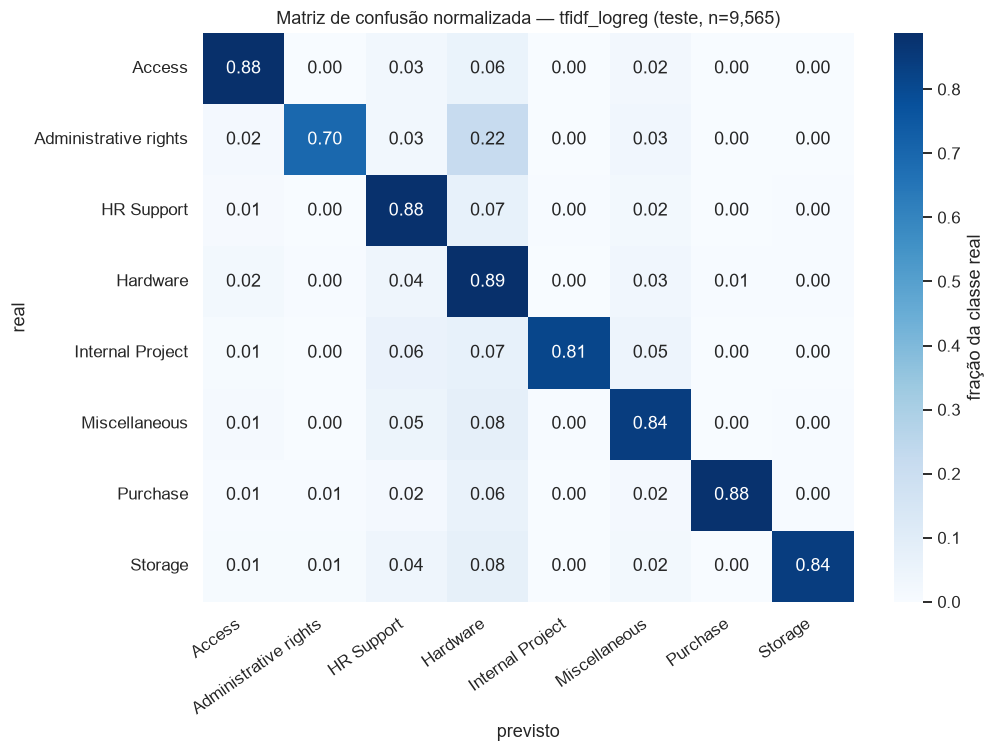

Maior confusão: Administrative rights -> Hardware (21.9% da classe real)


In [3]:
winner = [r for r in metrics["results"] if r["model"] == metrics["winner"]][0]
pc = pd.DataFrame(winner["per_class"]).T
pc = pc.loc[TOPIC_CLASSES, ["precision", "recall", "f1-score", "support"]].round(3)
print(pc.to_string())

cm = np.array(metrics["confusions"][metrics["winner"]])
cmn = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(9.5, 7))
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Blues", xticklabels=TOPIC_CLASSES,
            yticklabels=TOPIC_CLASSES, cbar_kws={"label": "fração da classe real"})
ax.set_xlabel("previsto"); ax.set_ylabel("real")
ax.set_title(f"Matriz de confusão normalizada — {metrics['winner']} (teste, n={int(cm.sum()):,})")
plt.xticks(rotation=35, ha="right")
fig.tight_layout(); fig.savefig(ASSETS / "ml_confusion.png", bbox_inches="tight"); plt.show()

off = cmn.copy(); np.fill_diagonal(off, 0)
i, j = np.unravel_index(off.argmax(), off.shape)
print(f"Maior confusão: {TOPIC_CLASSES[i]} -> {TOPIC_CLASSES[j]} ({off[i, j]:.1%} da classe real)")

## 3. Gate de confiança — cobertura × accuracy (liga com o fluxo da FASE 4)

O fluxo (FASE 4 §6, etapa 3) só permite ação automática acima do threshold; abaixo, a IA sugere e o humano
decide. Critério: menor threshold com **accuracy ≥ 90% nos tickets cobertos** (maximiza cobertura sob o gate).

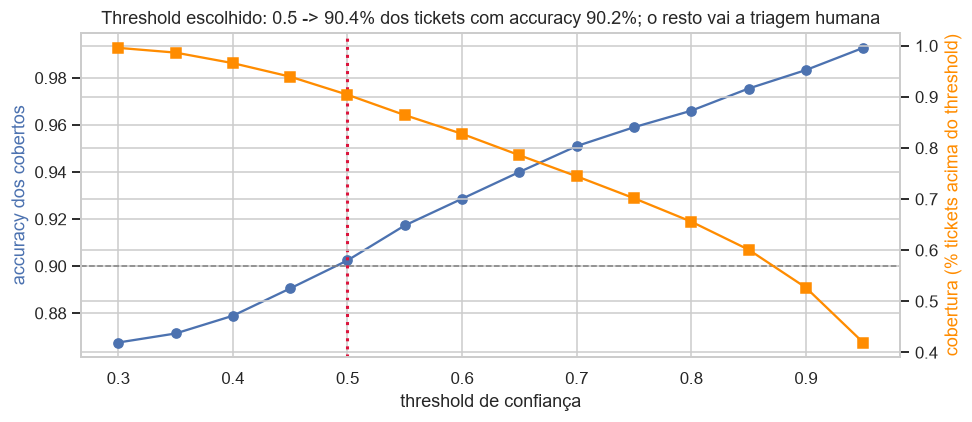

 threshold  coverage  accuracy_covered  n_covered
      0.30  0.995923          0.867520       9526
      0.35  0.986618          0.871357       9437
      0.40  0.966022          0.878896       9240
      0.45  0.939571          0.890509       8987
      0.50  0.904234          0.902416       8649
      0.55  0.864401          0.917271       8268
      0.60  0.827705          0.928635       7917
      0.65  0.785886          0.940003       7517
      0.70  0.744694          0.951004       7123
      0.75  0.701725          0.959029       6712
      0.80  0.655933          0.966050       6274
      0.85  0.601150          0.975478       5750
      0.90  0.526921          0.983333       5040
      0.95  0.419446          0.992772       4012


In [4]:
curve = pd.DataFrame(metrics["threshold_curve"])
thr = metrics["threshold"]
row = curve[curve["threshold"] == thr].iloc[0]
fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(curve["threshold"], curve["accuracy_covered"], "o-", color=BLUE, label="accuracy dos cobertos")
ax1.axhline(0.90, ls="--", color="gray", lw=1)
ax1.set_xlabel("threshold de confiança"); ax1.set_ylabel("accuracy dos cobertos", color=BLUE)
ax2 = ax1.twinx()
ax2.plot(curve["threshold"], curve["coverage"], "s-", color="darkorange", label="cobertura")
ax2.set_ylabel("cobertura (% tickets acima do threshold)", color="darkorange")
ax1.axvline(thr, color="crimson", ls=":", lw=2)
ax1.set_title(f"Threshold escolhido: {thr} -> {row['coverage']:.1%} dos tickets com accuracy "
              f"{row['accuracy_covered']:.1%}; o resto vai a triagem humana")
fig.tight_layout(); fig.savefig(ASSETS / "ml_threshold.png", bbox_inches="tight"); plt.show()
print(curve.to_string(index=False))

### 3.1 Calibração: a confiança significa o que diz?

            conf_media  acc_observada     n
conf_bin                                   
(0.3, 0.4]       0.363          0.500   286
(0.4, 0.5]       0.454          0.535   591
(0.5, 0.6]       0.548          0.619   732
(0.6, 0.7]       0.650          0.728   794
(0.7, 0.8]       0.751          0.840   849
(0.8, 0.9]       0.855          0.895  1234
(0.9, 1.0]       0.975          0.983  5040


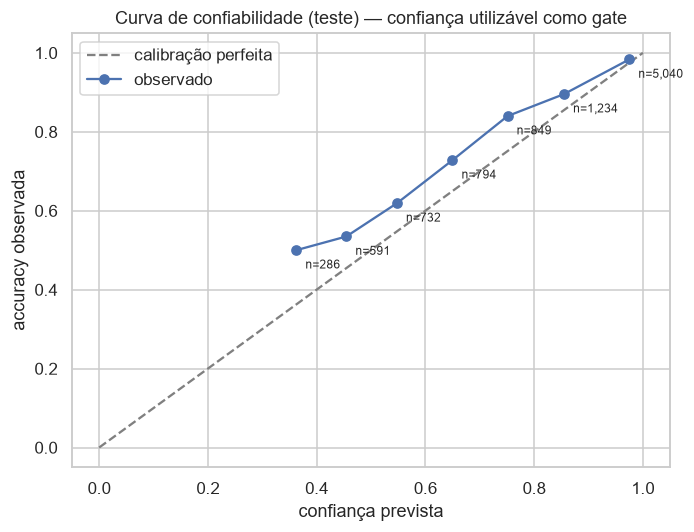

In [5]:
preds["correct"] = preds["pred"] == preds["Topic_group"].astype(str)
bins = np.arange(0.3, 1.01, 0.1)
preds["conf_bin"] = pd.cut(preds["confidence"], bins)
cal = preds.groupby("conf_bin", observed=True).agg(
    conf_media=("confidence", "mean"), acc_observada=("correct", "mean"), n=("correct", "size"))
print(cal.round(3).to_string())

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.plot([0, 1], [0, 1], "--", color="gray", label="calibração perfeita")
ax.plot(cal["conf_media"], cal["acc_observada"], "o-", color=BLUE, label="observado")
for _, r in cal.iterrows():
    ax.annotate(f"n={r['n']:,.0f}", (r["conf_media"], r["acc_observada"]),
                textcoords="offset points", xytext=(6, -12), fontsize=8)
ax.set_xlabel("confiança prevista"); ax.set_ylabel("accuracy observada")
ax.set_title("Curva de confiabilidade (teste) — confiança utilizável como gate")
ax.legend()
fig.tight_layout(); fig.savefig(ASSETS / "ml_calibration.png", bbox_inches="tight"); plt.show()

## 4. Análise de erros (foco: Miscellaneous — D-007)

In [6]:
misc = preds[preds["Topic_group"].astype(str) == "Miscellaneous"]
print(f"Miscellaneous no teste: n={len(misc):,} | accuracy={misc['correct'].mean():.3f} | "
      f"confiança média={misc['confidence'].mean():.3f}")
print(f"Demais classes:        accuracy={preds[preds['Topic_group'].astype(str) != 'Miscellaneous']['correct'].mean():.3f} | "
      f"confiança média={preds[preds['Topic_group'].astype(str) != 'Miscellaneous']['confidence'].mean():.3f}")
gate = preds[preds["confidence"] < metrics["threshold"]]
print(f"\nDos tickets ABAIXO do gate ({len(gate):,} = {len(gate)/len(preds):.1%} do teste), "
      f"{(gate['Topic_group'].astype(str) == 'Miscellaneous').mean():.1%} são Miscellaneous")
print("-> o gate faz na prática o que a FASE 4 §4 pediu: a classe guarda-chuva cai para triagem humana.")

corpus = pd.read_parquet(MODELS_DIR / "corpus.parquet")
err = preds[~preds["correct"]].nlargest(3, "confidence")
print("\n3 erros com MAIOR confiança (piores casos para o gate):")
for _, r in err.iterrows():
    doc = corpus.loc[corpus["doc_id"] == r["doc_id"], "Document"].iloc[0]
    print(f"  real={r['Topic_group']} pred={r['pred']} conf={r['confidence']:.2f}: \"{doc[:100]}...\"")

Miscellaneous no teste: n=1,412 | accuracy=0.841 | confiança média=0.790
Demais classes:        accuracy=0.870 | confiança média=0.833

Dos tickets ABAIXO do gate (916 = 9.6% do teste), 19.1% são Miscellaneous
-> o gate faz na prática o que a FASE 4 §4 pediu: a classe guarda-chuva cai para triagem humana.

3 erros com MAIOR confiança (piores casos para o gate):
  real=Miscellaneous pred=Access conf=1.00: "now account chow chow..."
  real=HR Support pred=Administrative rights conf=1.00: "connect the intern to outlook connect intern..."
  real=HR Support pred=Miscellaneous conf=1.00: "add towers watson tuesday pm add towers hi please add supplier towers thanks help regards officer..."


## 5. Busca semântica (FAISS + MiniLM) — tickets semelhantes

In [7]:
ai = load_ticket_ai()
queries = [
    "cannot login to my account password expired please reset",
    "need approval to purchase new laptop for new employee",
    "shared drive out of space cannot save files",
]
for q in queries:
    c = ai.classify(q)
    print(f'QUERY: "{q}"')
    print(f"  classificação: {c['label']} (conf {c['confidence']:.2f}; "
          f"ação automática: {'SIM' if c['auto_ok'] else 'NÃO -> humano'}; top3 {[(l, round(p, 2)) for l, p in c['top3']]})")
    sim = ai.find_similar(q, k=3)
    for _, s in sim.iterrows():
        print(f"    [{s['similarity']:.2f}] ({s['Topic_group']}) {s['Document'][:90]}...")
    print()

QUERY: "cannot login to my account password expired please reset"
  classificação: Access (conf 1.00; ação automática: SIM; top3 [(np.str_('Access'), 1.0), (np.str_('Storage'), 0.0), (np.str_('Hardware'), 0.0)])


D:\TB\ai-master-challenge-thales\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7547.01it/s]

    [0.80] (Access) unable to log after password reset unable log into with password...
    [0.80] (Access) password reset sent wednesday password reset hi can you please be kind reset password for ...
    [0.79] (Access) cannot log to password reset wednesday pm re expire days help cannot anymore expire days d...

QUERY: "need approval to purchase new laptop for new employee"
  classificação: Hardware (conf 0.62; ação automática: SIM; top3 [(np.str_('Hardware'), 0.62), (np.str_('Miscellaneous'), 0.25), (np.str_('HR Support'), 0.04)])


...

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8566.25it/s]

    [0.67] (Hardware) urgent request dear we please raise for urgent purchase laptop same for approved thank you...
    [0.66] (Hardware) laptop for new employee not provided re employee needs working laptop hello can someone pi...
    [0.65] (Hardware) new laptop november pm hi procedure obviously agreement requisition regards...

QUERY: "shared drive out of space cannot save files"
  classificação: Storage (conf 0.93; ação automática: SIM; top3 [(np.str_('Storage'), 0.93), (np.str_('Hardware'), 0.04), (np.str_('Access'), 0.01)])


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9151.66it/s]

    [0.61] (Storage) missing folder sent wednesday march folder issue hello colleagues currently trying access ...
    [0.57] (Storage) access to storage to storage hi guys please shared folder thanks...
    [0.57] (Hardware) no space on drive sent wednesday march space drive hi seems only left with small available...



## 6. Síntese e limitações

**Limitações declaradas:**
1. **Domínio:** o modelo classifica TI corporativo (D2); no contexto B2C do challenge, o pipeline seria
   re-treinado com tickets reais rotulados na taxonomia da FASE 4 §2 — arquitetura, gate e guardrails
   transferem; pesos não (ponte na FASE 4 §5).
2. **Texto pré-processado:** o D2 chega sem stopwords/pontuação — favorece TF-IDF e penaliza levemente
   sentence-transformers (treinados com texto natural); em produção com texto cru, a comparação deve ser refeita.
3. **Threshold escolhido no teste:** em produção, calibrar em janela separada e re-verificar por classe.
4. Embeddings em CPU (MiniLM) — em produção, avaliar modelo maior/GPU se a fila exigir.

Conclusões completas: [`docs/ml_models.md`](../docs/ml_models.md).